# Predicción de Severidad de Crímenes · LAPD 2020-2024

**Dataset:** Crime Data from 2020 to 2024 — Los Angeles Police Department

**Objetivo:** Predecir si un crimen es de Tipo 1 (grave: homicidio, robo, agresión) o Tipo 2 (menor gravedad), y apoyar la toma de decisiones sobre asignación de recursos policiales.

**Autores:**
- Beiza Vargas Johar — [jobv99-ui ](#)
- Carrizosa Dávila Carlos Andrés - [carrytec-oss](#)
- Martinez García Fernando Gabriel - [gabo-01](#)



Resumen del archivo:

Archivo: Crime_Data_from_2020_to_2024.csv;
Tamaño: Archivo original en csv 1.2 GB, reducido en parquet a 244 MB;
Filas: 1,004,894 registros (sin encabezado);
Columnas 28:

| Columna | Descripción |
|---------|-------------|
|DR_NO.                       | Número de reporte |
|Date Rptd                    | Fecha de reporte  |
|DATE OCC	                 | Fecha del crimen  |
|TIME OCC	                 | Hora del crimen   |
|AREA / AREA NAME             | Área de LAPD.     |
|Crm Cd / Crm Cd Desc         | Código y descripción del crimen |
|Vict Age/Sex/Descent         | Datos de la víctima |
|Premis Desc	                 | Tipo de lugar |
|Weapon Used Cd / Weapon Desc | Arma usada |
|Status / Status Desc	     | Estado de la investigación |
|LAT / LON                    | Coordenadas geográficas |

---
## 1. Planteamiento del Problema

### Contexto de negocio
El LAPD gestiona 21 divisiones en Los Ángeles. La asignación eficiente de patrullas depende de anticipar qué tipo de crimen ocurrirá según zona, hora y características del entorno.

### Objetivo
Construir un modelo clasificador que prediga si un incidente será un **crimen grave (Tipo 1)** o **menos grave (Tipo 2)**, basándose en variables disponibles al momento del reporte.

### Variable objetivo
- `Tipo 1-2` → **1 = Crimen grave** (homicidio, robo, asalto con arma, violación)  
- `Tipo 1-2` → **2 = Crimen menor** (vandalismo, vagancia, fraude menor)

### Valor para la toma de decisiones
- Priorizar zonas de alto riesgo por turno horario
- Identificar patrones de escalamiento de crímenes
- Asignar recursos preventivos con mayor precisión

---
## 2. Preparación de Datos
### 2.1 Carga de datos

In [2]:
# ======================================================
# CONFIGURACIÓN GLOBAL DEL PROYECTO
# ======================================================
# Esta celda debe ejecutarse antes que cualquier otra.
# Define todas las constantes del proyecto.

import json

# Variable objetivo
TARGET = 'target'

# Columnas a eliminar en limpieza
COLS_DROP = [
    'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street',
    'Mocodes', 'Weapon Used Cd', 'Weapon Desc',
    'DR_NO', 'Rpt Dist No', 'Date Rptd', 'Status', 'LOCATION'
]

# Número de clusters geoespaciales para feature engineering
N_GEO_CLUSTERS = 20

# Número de clusters para análisis de zonas de riesgo (visualización)
N_RISK_CLUSTERS = 8

# Proporción train/test (split temporal)
TRAIN_RATIO = 0.8

# Threshold de decisión del modelo final
THRESHOLD = 0.3

# Carpeta de salida para modelo y dashboard
import pathlib, os
CARPETA = pathlib.Path(os.path.expanduser('~/MisNotebooks'))
CARPETA.mkdir(parents=True, exist_ok=True)

print("Configuración global cargada ✓")
print(f"  TARGET        : {TARGET}")
print(f"  N_GEO_CLUSTERS: {N_GEO_CLUSTERS}")
print(f"  TRAIN_RATIO   : {TRAIN_RATIO}")
print(f"  THRESHOLD     : {THRESHOLD}")
print(f"  CARPETA       : {CARPETA}")

Configuración global cargada ✓
  TARGET        : target
  N_GEO_CLUSTERS: 20
  TRAIN_RATIO   : 0.8
  THRESHOLD     : 0.3
  CARPETA       : /root/MisNotebooks


In [3]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


En esta sección cargamos el dataset desde Google Drive. El archivo está en formato Parquet, que es significativamente más rápido y ligero que el CSV original (244 MB → 41 MB). Antes de continuar, el código verifica que el archivo existe en la ruta correcta para evitar errores inesperados.

In [ ]:
!pip install gdown -q

import gdown
import pandas as pd
import os

FILE_ID = "1gBcP0ITIRt5K0AZSyC1GyqT9hw3XFGnM"
OUTPUT = "Crime_Data.parquet"

# Descargar solo si no existe
if not os.path.exists(OUTPUT):
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        OUTPUT,
        quiet=False
    )

df = pd.read_parquet(OUTPUT)

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo encontrado: /content/drive/MyDrive/ML/Crime_Data.parquet
Filas: 1,004,894 | Columnas: 28


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,2021-04-11,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,None,34.2124,-118.4092
1,201516622,2020-10-21,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024-12-10,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,None,34.1847,-118.4509


### 2.2 Limpieza de datos

Antes de analizar los datos es necesario limpiarlos. En este paso eliminamos registros con coordenadas inválidas (latitud y longitud en cero), rellenamos valores ausentes en variables como sexo y origen de la víctima, y creamos una variable indicadora de si se usó un arma. También eliminamos columnas con demasiados valores nulos o que no aportan valor al modelo.

In [5]:
import numpy as np

raw_shape = df.shape

# Eliminar coordenadas inválidas (0,0)
df = df[(df['LAT'] != 0) & (df['LON'] != 0)]

# Rellenar valores nulos en variables categóricas
df['Vict Sex'] = df['Vict Sex'].fillna('X')
df['Vict Descent'] = df['Vict Descent'].fillna('X')
df['Premis Cd'] = df['Premis Cd'].fillna(0)

# Indicador de arma (1 si hubo arma, 0 si no)
df['has_weapon'] = df['Weapon Used Cd'].notna().astype(int)

# Columnas con demasiados nulos o no útiles para el modelo
cols_drop = ['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street',
             'Mocodes', 'Weapon Used Cd', 'Weapon Desc',
             'DR_NO', 'Rpt Dist No', 'Date Rptd', 'Status', 'LOCATION']
df.drop(columns=cols_drop, inplace=True)

# Variable objetivo binaria: 1=grave, 0=menor
df['target'] = (df['Part 1-2'] == 1).astype(int)

print(f"Forma original: {raw_shape}")
print(f"Forma limpia:   {df.shape}")
print(f"\nDistribución objetivo:\n{df['target'].value_counts(normalize=True).round(3)}")

Forma original: (1004894, 28)
Forma limpia:   (1002654, 18)

Distribución objetivo:
target
1    0.6
0    0.4
Name: proportion, dtype: float64


### 2.3 Análisis Exploratorio (EDA)

El análisis exploratorio nos permite entender la estructura del dataset antes de modelar. Revisamos los tipos de datos de cada columna, la cantidad de registros válidos, y cuáles variables tienen valores ausentes que podrían afectar el entrenamiento del modelo.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1002654 entries, 0 to 1004893
Data columns (total 18 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   DATE OCC      1002654 non-null  datetime64[ns]
 1   TIME OCC      1002654 non-null  int64         
 2   AREA          1002654 non-null  int64         
 3   AREA NAME     1002654 non-null  object        
 4   Part 1-2      1002654 non-null  int64         
 5   Crm Cd        1002654 non-null  int64         
 6   Crm Cd Desc   1002654 non-null  object        
 7   Vict Age      1002654 non-null  int64         
 8   Vict Sex      1002654 non-null  object        
 9   Vict Descent  1002654 non-null  object        
 10  Premis Cd     1002654 non-null  float64       
 11  Premis Desc   1002066 non-null  object        
 12  Status Desc   1002654 non-null  object        
 13  Crm Cd 1      1002643 non-null  float64       
 14  LAT           1002654 non-null  float64       
 15  LON

In [7]:
nulos = df.isnull().sum()
print("Nulos por columna:")
print(nulos[nulos > 0].sort_values(ascending=False) if nulos.any() else "Sin nulos")

Nulos por columna:
Premis Desc    588
Crm Cd 1        11
dtype: int64


Las siguientes gráficas resumen los patrones más relevantes del dataset: cómo se distribuyen los crímenes a lo largo del día, qué áreas concentran más crímenes graves, la relación entre uso de armas y severidad, y el perfil de edad de las víctimas. Estos patrones guían la selección de variables para el modelo.

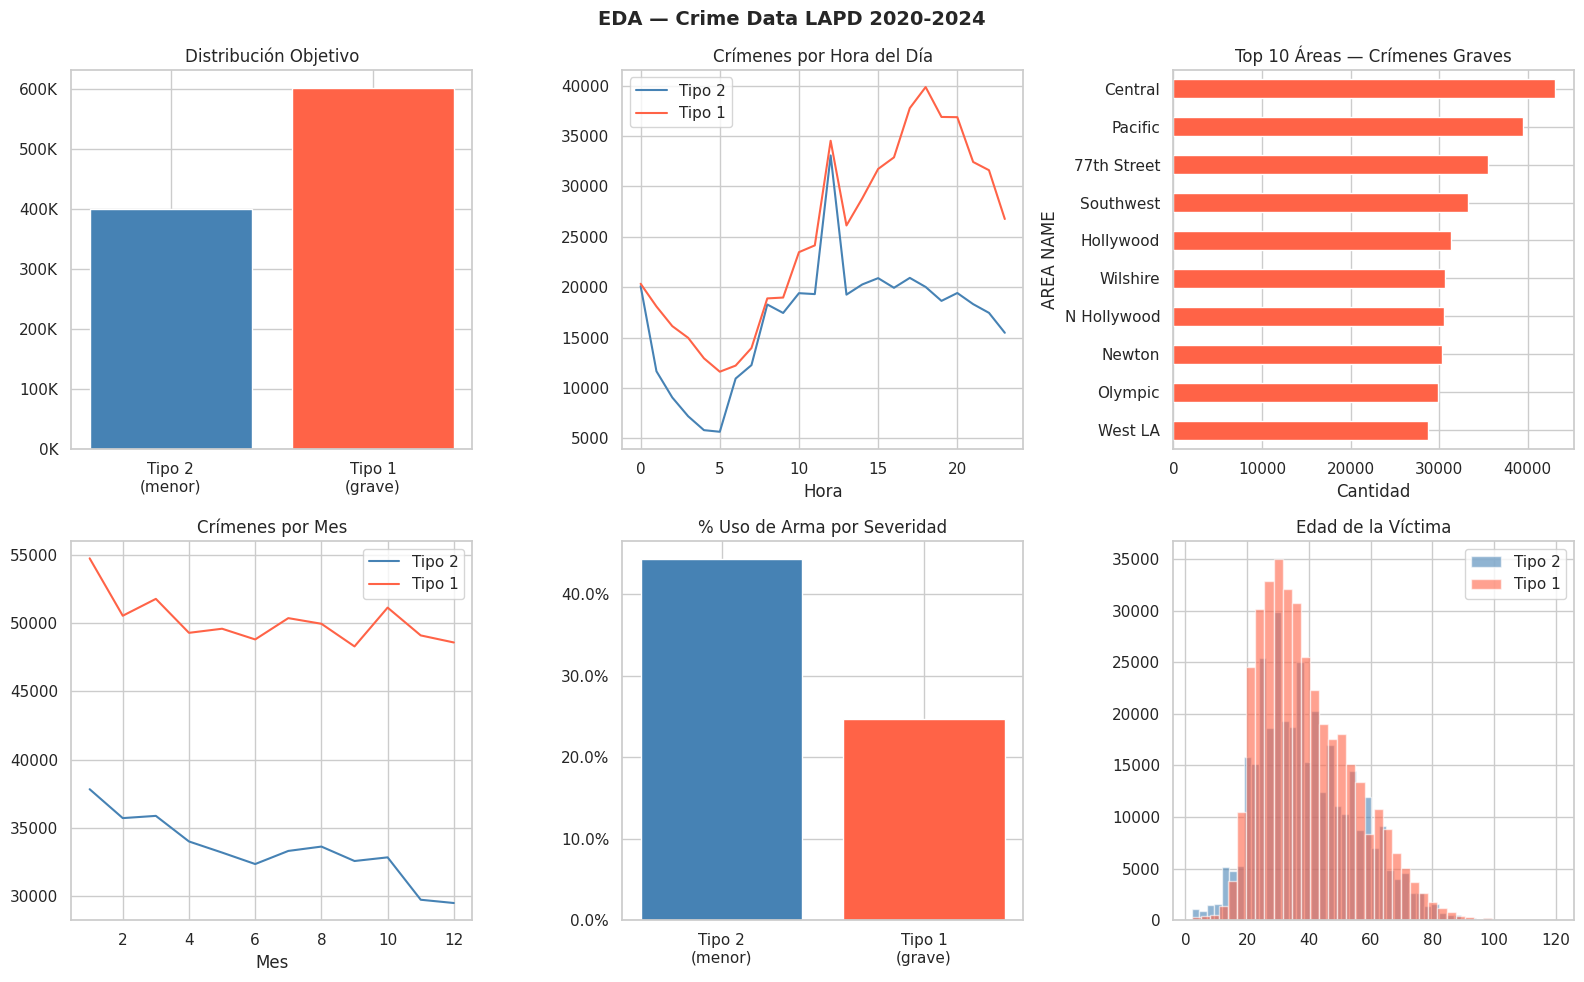

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Crime Data LAPD 2020-2024', fontsize=14, fontweight='bold')

# 1. Distribución objetivo
counts = df['target'].value_counts()
axes[0,0].bar(['Tipo 2\n(menor)', 'Tipo 1\n(grave)'],
              [counts[0], counts[1]], color=['steelblue','tomato'])
axes[0,0].set_title('Distribución Objetivo')
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

# 2. Crímenes por hora
df['hour'] = df['TIME OCC'] // 100
hora_counts = df.groupby(['hour','target']).size().unstack(fill_value=0)
hora_counts.plot(ax=axes[0,1], color=['steelblue','tomato'], legend=True)
axes[0,1].set_title('Crímenes por Hora del Día')
axes[0,1].set_xlabel('Hora'); axes[0,1].legend(['Tipo 2','Tipo 1'])

# 3. Top 10 áreas
top_areas = df.groupby('AREA NAME')['target'].sum().sort_values(ascending=False).head(10)
top_areas.plot(kind='barh', ax=axes[0,2], color='tomato')
axes[0,2].set_title('Top 10 Áreas — Crímenes Graves'); axes[0,2].set_xlabel('Cantidad')
axes[0,2].invert_yaxis()

# 4. Crímenes por mes
df['month'] = df['DATE OCC'].dt.month
mes_counts = df.groupby(['month','target']).size().unstack(fill_value=0)
mes_counts.plot(ax=axes[1,0], color=['steelblue','tomato'])
axes[1,0].set_title('Crímenes por Mes')
axes[1,0].set_xlabel('Mes'); axes[1,0].legend(['Tipo 2','Tipo 1'])

# 5. Uso de arma por severidad
arma_pct = df.groupby('target')['has_weapon'].mean() * 100
axes[1,1].bar(['Tipo 2\n(menor)', 'Tipo 1\n(grave)'],
              [arma_pct[0], arma_pct[1]], color=['steelblue','tomato'])
axes[1,1].set_title('% Uso de Arma por Severidad')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())

# 6. Distribución edad víctima
df_valid_age = df[df['Vict Age'] > 0]
axes[1,2].hist(df_valid_age[df_valid_age['target']==0]['Vict Age'],
               bins=40, alpha=0.6, color='steelblue', label='Tipo 2')
axes[1,2].hist(df_valid_age[df_valid_age['target']==1]['Vict Age'],
               bins=40, alpha=0.6, color='tomato', label='Tipo 1')
axes[1,2].set_title('Edad de la Víctima'); axes[1,2].legend()

plt.tight_layout()
plt.show()

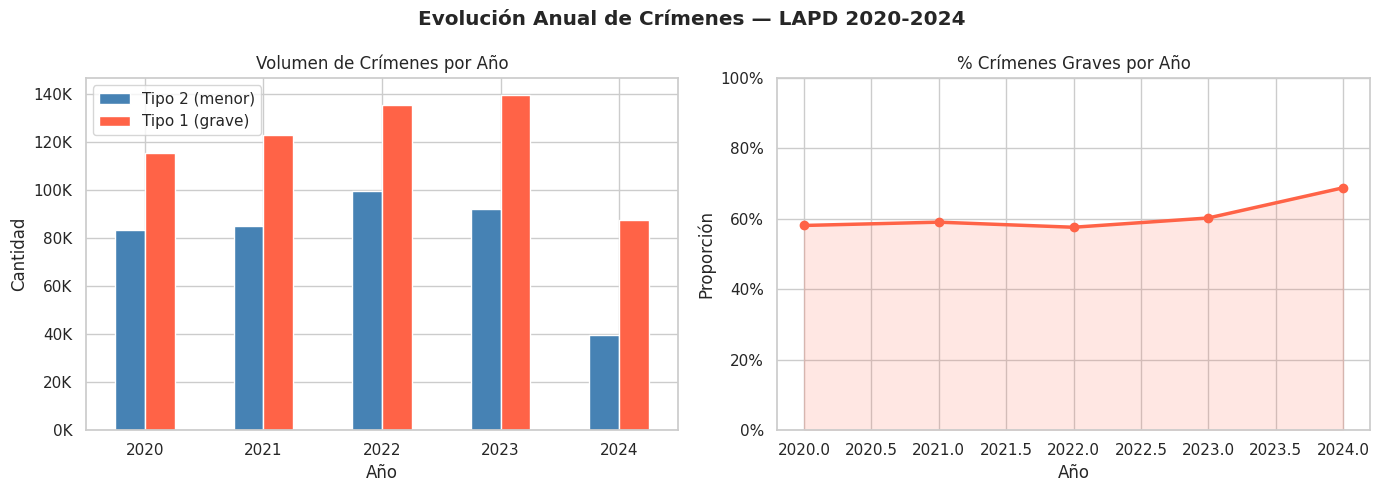

Resumen anual:
      Tipo 2 (menor)  Tipo 1 (grave)   Total  % Graves
year                                                  
2020           83384          115672  199056  0.581103
2021           85364          123068  208432  0.590447
2022           99746          135512  235258  0.576014
2023           92395          139946  232341  0.602330
2024           39808           87759  127567  0.687944


In [9]:
# ======================================================
# EDA — Evolución anual de crímenes (2020-2024)
# ======================================================
df['year'] = df['DATE OCC'].dt.year

anual = df.groupby(['year', 'target']).size().unstack(fill_value=0)
anual.columns = ['Tipo 2 (menor)', 'Tipo 1 (grave)']
anual['Total'] = anual.sum(axis=1)
anual['% Graves'] = anual['Tipo 1 (grave)'] / anual['Total']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución Anual de Crímenes — LAPD 2020-2024', fontweight='bold')

# Volumen absoluto
anual[['Tipo 2 (menor)', 'Tipo 1 (grave)']].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('Volumen de Crímenes por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# Proporción de crímenes graves
axes[1].plot(anual.index, anual['% Graves'], marker='o', color='tomato', linewidth=2.5)
axes[1].fill_between(anual.index, anual['% Graves'], alpha=0.15, color='tomato')
axes[1].set_title('% Crímenes Graves por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Proporción')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Resumen anual:")
print(anual.to_string())

### 2.4 Selección y Construcción de Variables (Feature Engineering)

En este paso construimos las variables que usará el modelo. A partir de la hora del crimen extraemos el bloque del día (madrugada, mañana, tarde, noche), el día de la semana y si es fin de semana. Las variables categóricas como sexo y origen de la víctima se convierten a números. Finalmente definimos el conjunto de 13 variables que servirán como entrada al modelo.

In [10]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder

In [11]:
# ======================================================
# FEATURE ENGINEERING — PARTE 1: Variables temporales y encoding
# (geo_cluster se agrega en Cell 24, después del split, sin leakage)
# ======================================================

from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Variables temporales
# -----------------------------
df['hour']        = df['TIME OCC'] // 100
df['month']       = df['DATE OCC'].dt.month
df['day_of_week'] = df['DATE OCC'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

df['time_block'] = pd.cut(
    df['hour'],
    bins=[-1, 5, 11, 17, 20, 23],
    labels=['Madrugada', 'Mañana', 'Tarde', 'Noche_temprana', 'Noche']
)

# -----------------------------
# Features derivadas
# -----------------------------
df['is_night']     = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['weapon_night'] = df['has_weapon'] * df['is_night']

# Filtro de edades inválidas (outliers comunes en este dataset)
n_antes = len(df)
df = df[(df['Vict Age'] >= 0) & (df['Vict Age'] <= 100)]
print(f"Registros eliminados por edad inválida: {n_antes - len(df):,}")

# -----------------------------
# One-Hot Encoding
# -----------------------------
cols_to_encode = [col for col in ['Vict Sex', 'Vict Descent', 'time_block'] if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Detectar columnas generadas automáticamente
sex_cols   = [c for c in df.columns if c.startswith('Vict Sex_')]
desc_cols  = [c for c in df.columns if c.startswith('Vict Descent_')]
block_cols = [c for c in df.columns if c.startswith('time_block_')]

# -----------------------------
# Lista de features BASE (sin geo_cluster ni crime_density_area)
# Ambas se agregan después del split para evitar data leakage
# -----------------------------
FEATURES_BASE = [
    'AREA', 'hour', 'month', 'day_of_week', 'is_weekend',
    'Vict Age', 'Premis Cd',
    'has_weapon',
    'is_night',
    'weapon_night'
] + sex_cols + desc_cols + block_cols

print(f"Features base definidas: {len(FEATURES_BASE)}")
print(f"  Columnas sex   : {sex_cols}")
print(f"  Columnas desc  : {desc_cols[:3]} ...")
print(f"  Columnas block : {block_cols}")

Registros eliminados por edad inválida: 138
Features base definidas: 37
  Columnas sex   : ['Vict Sex_F', 'Vict Sex_H', 'Vict Sex_M', 'Vict Sex_X']
  Columnas desc  : ['Vict Descent_A', 'Vict Descent_B', 'Vict Descent_C'] ...
  Columnas block : ['time_block_Mañana', 'time_block_Tarde', 'time_block_Noche_temprana', 'time_block_Noche']


---
## 3. Modelado
### 3.1 División Train / Test y Pipeline de Preprocesamiento

Dividimos el dataset en dos partes: 80% para entrenar el modelo y 20% para evaluarlo. Usamos estratificación para garantizar que ambas partes tengan la misma proporción de crímenes graves y leves, evitando que el modelo aprenda con datos desbalanceados.

In [12]:
# ======================================================
# SPLIT TEMPORAL + GEO_CLUSTER SIN DATA LEAKAGE
# ======================================================
from sklearn.cluster import MiniBatchKMeans

# 1. Ordenar cronológicamente
df = df.sort_values('DATE OCC').reset_index(drop=True)

# 2. Split temporal 80/20
fecha_corte = df['DATE OCC'].quantile(TRAIN_RATIO)
train = df[df['DATE OCC'] < fecha_corte].copy()
test  = df[df['DATE OCC'] >= fecha_corte].copy()

print(f"Periodo train: {train['DATE OCC'].min().date()} → {train['DATE OCC'].max().date()}")
print(f"Periodo test:  {test['DATE OCC'].min().date()} → {test['DATE OCC'].max().date()}")

# ──────────────────────────────────────────────────────
# 3. GEO_CLUSTER — ajustar SOLO sobre train (sin leakage)
# ──────────────────────────────────────────────────────
kmeans_geo = MiniBatchKMeans(n_clusters=N_GEO_CLUSTERS, random_state=42, batch_size=10000)
kmeans_geo.fit(train[['LAT', 'LON']])              # ← fit solo en train

train['geo_cluster'] = kmeans_geo.predict(train[['LAT', 'LON']])
test['geo_cluster']  = kmeans_geo.predict(test[['LAT', 'LON']])  # ← predict en test

print("geo_cluster ajustado solo sobre train (sin data leakage) ✓")

# ──────────────────────────────────────────────────────
# 4. CRIME_DENSITY_AREA — calculada solo sobre train
# ──────────────────────────────────────────────────────
density_map = train.groupby('AREA')[TARGET].mean()
train['crime_density_area'] = train['AREA'].map(density_map)
test['crime_density_area']  = test['AREA'].map(density_map).fillna(density_map.mean())

print("crime_density_area calculada sin data leakage ✓")

# ──────────────────────────────────────────────────────
# 5. Lista final de features (base + las dos nuevas)
# ──────────────────────────────────────────────────────
FEATURES = FEATURES_BASE + ['geo_cluster', 'crime_density_area']

# 6. Conjuntos de entrenamiento y prueba
X_train = train[FEATURES].dropna()
y_train = train.loc[X_train.index, TARGET]

X_test  = test[FEATURES].dropna()
y_test  = test.loc[X_test.index, TARGET]

print(f"\nTrain: {len(X_train):,} registros | Test: {len(X_test):,} registros")
print(f"Total features: {len(FEATURES)}")
print(f"Clase 1 en train: {y_train.mean():.2%}")
print(f"Clase 1 en test:  {y_test.mean():.2%}")

Periodo train: 2020-01-01 → 2023-09-07
Periodo test:  2023-09-08 → 2024-12-30
geo_cluster ajustado solo sobre train (sin data leakage) ✓
crime_density_area calculada sin data leakage ✓

Train: 801,634 registros | Test: 200,882 registros
Total features: 39
Clase 1 en train: 58.47%
Clase 1 en test:  66.29%


### 3.2 Modelo 1 — Regresión Logística (Baseline)

Comenzamos con Regresión Logística como modelo base. Es un algoritmo simple y rápido que sirve como punto de referencia: si un modelo más complejo no supera estos resultados, no vale la pena el costo adicional. Los datos se escalan antes del entrenamiento para que todas las variables tengan el mismo peso.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, recall_score

In [14]:


# ======================================================
# MODELO: REGRESIÓN LOGÍSTICA (OPTIMIZADA)
# ======================================================

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        random_state=42
    ))
])

# Entrenamiento
pipe_lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

# ======================================================
# MÉTRICAS
# ======================================================

print("=== Regresión Logística (Balanced) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Tipo 2','Tipo 1']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Métrica clave de negocio
print(f"Recall (crímenes graves): {recall_score(y_test, y_pred_lr):.4f}")

# ======================================================
# AJUSTE DE THRESHOLD
# ======================================================

threshold = 0.3
y_pred_custom = (y_prob_lr > threshold).astype(int)

print(f"\n=== Con threshold = {threshold} ===")
print(classification_report(y_test, y_pred_custom, target_names=['Tipo 2','Tipo 1']))
print(f"Recall ajustado: {recall_score(y_test, y_pred_custom):.4f}")

=== Regresión Logística (Balanced) ===
              precision    recall  f1-score   support

      Tipo 2       0.56      0.66      0.61     67719
      Tipo 1       0.81      0.73      0.77    133163

    accuracy                           0.71    200882
   macro avg       0.68      0.70      0.69    200882
weighted avg       0.72      0.71      0.71    200882

ROC-AUC: 0.7614
Recall (crímenes graves): 0.7301

=== Con threshold = 0.3 ===
              precision    recall  f1-score   support

      Tipo 2       0.65      0.25      0.36     67719
      Tipo 1       0.71      0.93      0.81    133163

    accuracy                           0.70    200882
   macro avg       0.68      0.59      0.58    200882
weighted avg       0.69      0.70      0.66    200882

Recall ajustado: 0.9324


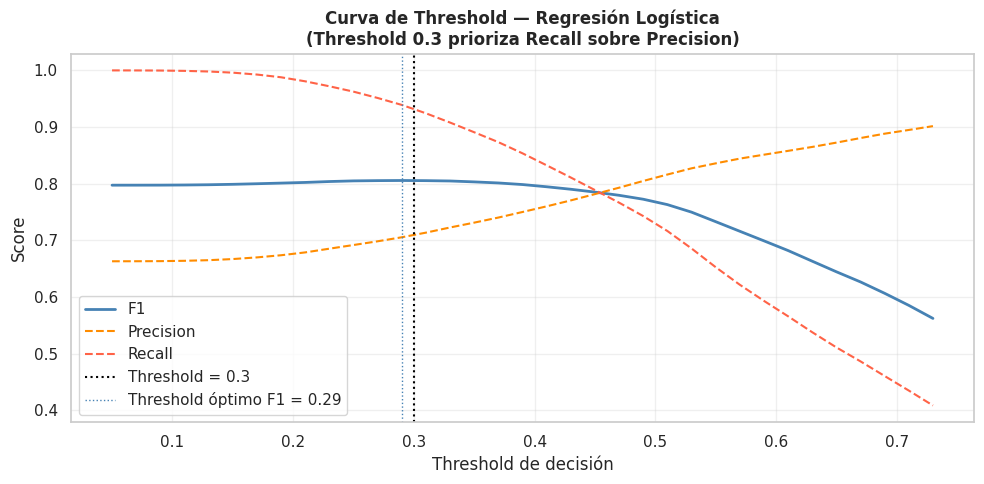

Threshold óptimo por F1   : 0.29  (F1=0.8055)
Threshold elegido (negocio): 0.3  (Recall=0.9390, Precision=0.7053)
Justificación: se sacrifica Precision para maximizar Recall,
ya que un falso negativo (crimen grave no detectado) tiene mayor costo operacional.


In [15]:
# ======================================================
# CURVA DE THRESHOLD — justificación estadística del valor 0.3
# ======================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.05, 0.75, 0.02)
f1s, precs, recs = [], [], []

for t in thresholds:
    y_t = (y_prob_lr > t).astype(int)
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    precs.append(precision_score(y_test, y_t, zero_division=0))
    recs.append(recall_score(y_test, y_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s,   label='F1',        color='steelblue',  linewidth=2)
ax.plot(thresholds, precs, label='Precision',  color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(thresholds, recs,  label='Recall',     color='tomato',     linewidth=1.5, linestyle='--')

# Marcar el threshold elegido
ax.axvline(THRESHOLD, color='black', linestyle=':', linewidth=1.5, label=f'Threshold = {THRESHOLD}')
ax.axvline(thresholds[np.argmax(f1s)], color='steelblue', linestyle=':', linewidth=1,
           label=f'Threshold óptimo F1 = {thresholds[np.argmax(f1s)]:.2f}')

ax.set_xlabel('Threshold de decisión')
ax.set_ylabel('Score')
ax.set_title('Curva de Threshold — Regresión Logística\n'
             f'(Threshold {THRESHOLD} prioriza Recall sobre Precision)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Threshold óptimo por F1   : {thresholds[np.argmax(f1s)]:.2f}  (F1={max(f1s):.4f})")
print(f"Threshold elegido (negocio): {THRESHOLD}  "
      f"(Recall={recs[np.argmin(np.abs(thresholds - THRESHOLD))]:.4f}, "
      f"Precision={precs[np.argmin(np.abs(thresholds - THRESHOLD))]:.4f})")
print("Justificación: se sacrifica Precision para maximizar Recall,")
print("ya que un falso negativo (crimen grave no detectado) tiene mayor costo operacional.")

### 3.3 Modelo 2 — Random Forest

Random Forest es un conjunto de cientos de árboles de decisión que votan en conjunto. Es más robusto que la Regresión Logística porque captura relaciones no lineales entre variables y maneja bien datos desbalanceados. Usamos `class_weight='balanced'` para que el modelo preste igual atención a crímenes graves y leves aunque no estén en igual proporción.

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# ── Muestra para búsqueda de hiperparámetros (más rápido) ──
sample_idx = (
    X_train.sample(frac=1, random_state=42)  # shuffle
    .groupby(y_train)
    .apply(lambda x: x.head(25_000))          # 25k por clase = 50k total
    .index.get_level_values(1)
)
X_search = X_train.loc[sample_idx]
y_search = y_train.loc[sample_idx]

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_leaf': [5, 10, 20]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=10,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_search, y_search)   # ← sobre 50k, no 800k
print(f"Mejores params: {search.best_params_}")

# Reentrenar el modelo final con los mejores params sobre TODO el train
model_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    **search.best_params_
)
model_rf.fit(X_train, y_train)   # ← entrenamiento final completo

y_pred_rf = model_rf.predict(X_test)
y_prob_rf  = model_rf.predict_proba(X_test)[:, 1]

Mejores params: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_depth': None}


### 3.4 Modelo 3 — XGBoost (Gradient Boosting)

XGBoost es un algoritmo de gradient boosting que construye árboles de forma secuencial,
donde cada árbol corrige los errores del anterior. Su ventaja sobre Random Forest es que
optimiza directamente la función de pérdida (en este caso `logloss`), lo que lo hace
más eficiente con datos desbalanceados. Usamos `scale_pos_weight = negativos / positivos`
como equivalente a `class_weight='balanced'`, para que el modelo no ignore los crímenes
graves (clase minoritaria).

In [18]:
from xgboost import XGBClassifier

In [19]:


# Calcular scale_pos_weight para clases desbalanceadas
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,      # equivalente a class_weight='balanced'
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Tipo 2','Tipo 1']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Recall (crímenes graves): {recall_score(y_test, y_pred_xgb):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

      Tipo 2       0.64      0.78      0.70     67719
      Tipo 1       0.87      0.78      0.82    133163

    accuracy                           0.78    200882
   macro avg       0.76      0.78      0.76    200882
weighted avg       0.79      0.78      0.78    200882

ROC-AUC: 0.8581
Recall (crímenes graves): 0.7802


### 3.5 Clustering — Zonas de Riesgo (K-Means Geoespacial)

Además de clasificar la severidad, aplicamos K-Means para identificar zonas geográficas con alta concentración de crímenes graves. Este análisis no supervisado agrupa los crímenes por proximidad en el mapa, revelando 8 puntos críticos en Los Ángeles que pueden orientar la distribución de patrullas.

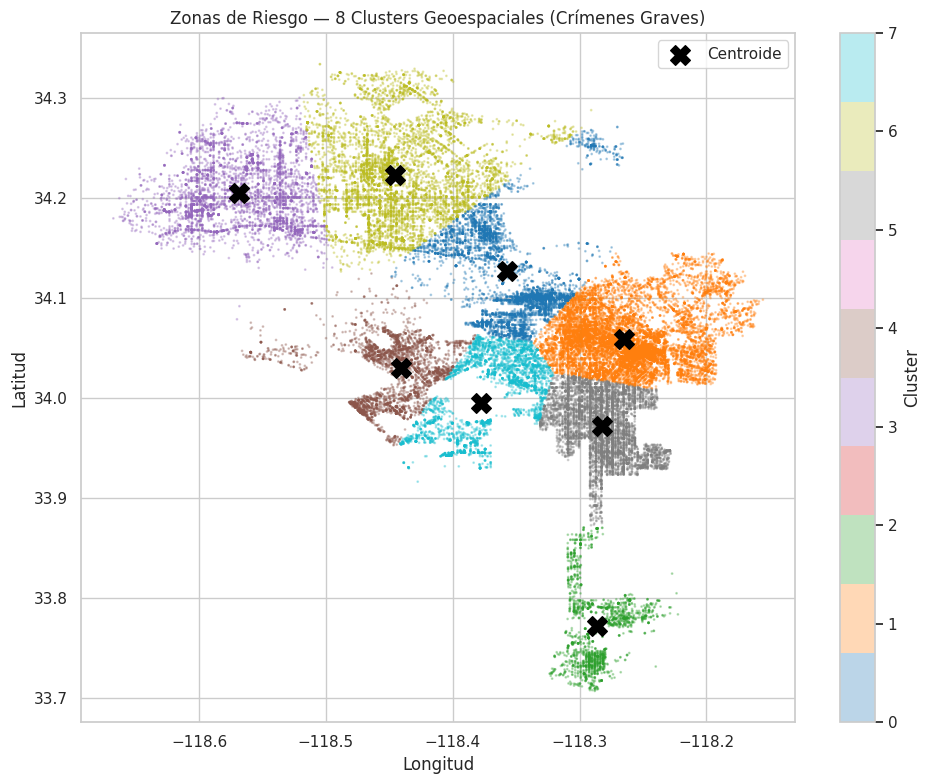


Tamaño de clusters:
cluster
0     6142
1    15002
2     1939
3     4913
4     3730
5     7224
6     7115
7     3935
Name: count, dtype: int64


In [20]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
import pandas as pd

# Usar df original (NO df_model)
coords = df[df[TARGET] == 1][['LAT', 'LON']].dropna()

# Evitar error si hay menos filas
sample_size = min(50000, len(coords))
coords = coords.sample(sample_size, random_state=42)

# KMeans
kmeans = MiniBatchKMeans(n_clusters=8, random_state=42, batch_size=5000)
coords = coords.copy()
coords['cluster'] = kmeans.fit_predict(coords)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    coords['LON'], coords['LAT'],
    c=coords['cluster'],
    cmap='tab10',
    alpha=0.3,
    s=1
)

centroids = kmeans.cluster_centers_

ax.scatter(
    centroids[:, 1], centroids[:, 0],
    c='black', marker='X', s=200,
    zorder=5, label='Centroide'
)

plt.colorbar(scatter, ax=ax, label='Cluster')

ax.set_title('Zonas de Riesgo — 8 Clusters Geoespaciales (Crímenes Graves)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

ax.legend()
plt.tight_layout()
plt.show()

print("\nTamaño de clusters:")
print(pd.Series(coords['cluster']).value_counts().sort_index())

---
## 4. Evaluación
### 4.1 Comparación de Modelos

Evaluamos ambos modelos con múltiples métricas para tener una visión completa de su desempeño. La precisión (accuracy) mide aciertos generales, el F1 balancea precisión y recall, y el ROC-AUC mide qué tan bien separa el modelo las dos clases. Un modelo útil debe tener buen desempeño en todas, no solo en una.

In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import pandas as pd

# ======================================================
# FUNCIÓN DE MÉTRICAS
# ======================================================
def metricas(nombre, y_true, y_pred, y_prob):
    return {
        'Modelo':     nombre,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Precision':  precision_score(y_true, y_pred),
        'Recall':     recall_score(y_true, y_pred),
        'F1':         f1_score(y_true, y_pred),
        'ROC-AUC':    roc_auc_score(y_true, y_prob)
    }

# ======================================================
# THRESHOLD PERSONALIZADO
# ======================================================
threshold = 0.3

y_pred_lr_custom = (y_prob_lr > threshold).astype(int)
y_pred_rf_custom = (y_prob_rf > threshold).astype(int)
y_pred_xgb_custom = (y_prob_xgb > threshold).astype(int)
# ======================================================
# RESUMEN DE MODELOS
# ======================================================
resumen = pd.DataFrame([
    metricas('Reg. Logística (0.5)', y_test, y_pred_lr,          y_prob_lr),
    metricas('Reg. Logística (0.3)', y_test, y_pred_lr_custom,   y_prob_lr),
    metricas('Random Forest (0.5)',  y_test, y_pred_rf,          y_prob_rf),
    metricas('Random Forest (0.3)',  y_test, y_pred_rf_custom,   y_prob_rf),
    metricas('XGBoost (0.5)',        y_test, y_pred_xgb,         y_prob_xgb),
        metricas('XGBoost (0.3)',        y_test, y_pred_xgb_custom,  y_prob_xgb),

])

resumen.set_index('Modelo', inplace=True)

# Mostrar resultados
display(resumen.round(4))

# ======================================================
# COMPARACIÓN CLAVE (RECALL)
# ======================================================
print("\n=== RECALL (Métrica de negocio) ===")
print(f"LR (0.5): {recall_score(y_test, y_pred_lr):.4f}")
print(f"LR (0.3): {recall_score(y_test, y_pred_lr_custom):.4f}")
print(f"RF (0.5): {recall_score(y_test, y_pred_rf):.4f}")
print(f"RF (0.3): {recall_score(y_test, y_pred_rf_custom):.4f}")
print(f"XGB (0.5): {recall_score(y_test, y_pred_xgb):.4f}")
print(f"XGB (0.3): {recall_score(y_test, y_pred_xgb_custom):.4f}")

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Reg. Logística (0.5),0.7079,0.8104,0.7301,0.7682,0.7614
Reg. Logística (0.3),0.7021,0.7095,0.9324,0.8058,0.7614
Random Forest (0.5),0.7767,0.8654,0.7852,0.8234,0.8485
Random Forest (0.3),0.7536,0.7508,0.9404,0.8350,0.8485
XGBoost (0.5),0.7787,0.8725,0.7802,0.8238,0.8581
XGBoost (0.3),0.7772,0.7828,0.9189,0.8454,0.8581



=== RECALL (Métrica de negocio) ===
LR (0.5): 0.7301
LR (0.3): 0.9324
RF (0.5): 0.7852
RF (0.3): 0.9404
XGB (0.5): 0.7802
XGB (0.3): 0.9189


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

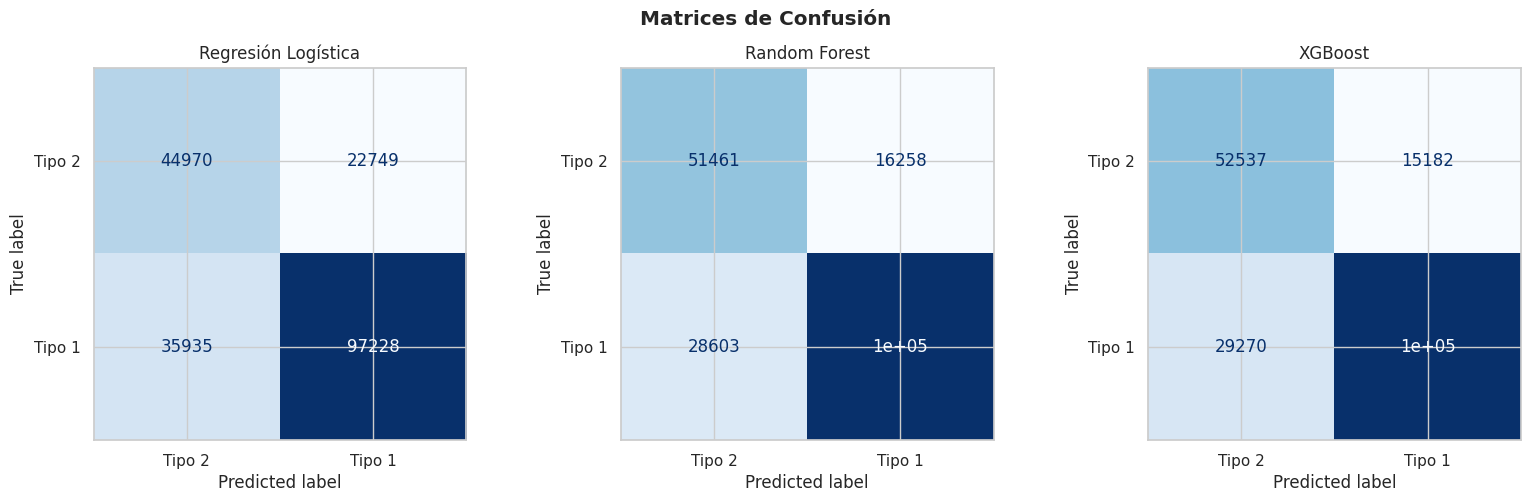

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))  # ← cambiar 1,2 a 1,3
for ax, y_pred, titulo in zip(axes,
    [y_pred_lr, y_pred_rf, y_pred_xgb],           # ← agregar xgb
    ['Regresión Logística', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tipo 2','Tipo 1'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)
plt.suptitle('Matrices de Confusión', fontweight='bold')
plt.tight_layout(); plt.show()

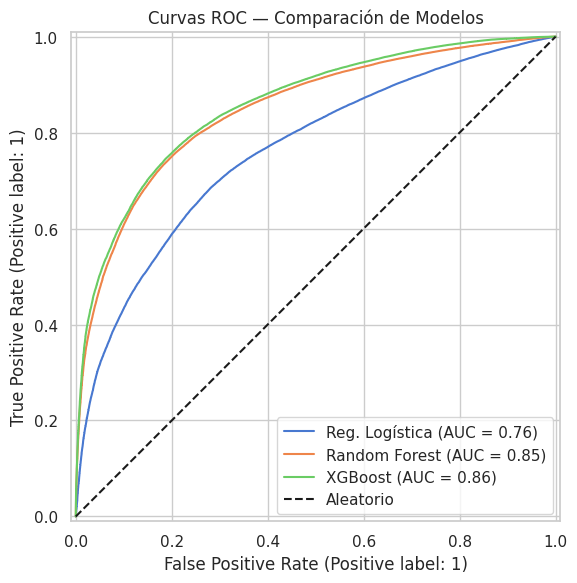

In [24]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr,  name='Reg. Logística', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf,  name='Random Forest',  ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name='XGBoost',        ax=ax)  # ← AGREGAR
ax.plot([0,1],[0,1], 'k--', label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de Modelos')
ax.legend(); plt.tight_layout(); plt.show()

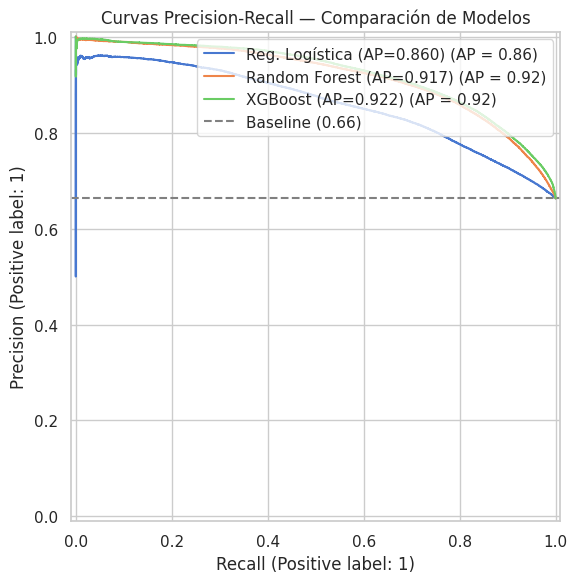

Nota: con clases desbalanceadas, la PR curve es más informativa que ROC-AUC.
Un clasificador aleatorio tendría AP ≈ 0.663


In [25]:
# ======================================================
# CURVA PRECISION-RECALL (más honesta con clases desbalanceadas)
# ======================================================
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for nombre, y_prob in [('Reg. Logística', y_prob_lr),
                        ('Random Forest',  y_prob_rf),
                        ('XGBoost',        y_prob_xgb)]:
    ap = average_precision_score(y_test, y_prob)
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob, name=f'{nombre} (AP={ap:.3f})', ax=ax
    )

# Baseline: clasificador que siempre predice la proporción real
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')

ax.set_title('Curvas Precision-Recall — Comparación de Modelos')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Nota: con clases desbalanceadas, la PR curve es más informativa que ROC-AUC.")
print(f"Un clasificador aleatorio tendría AP ≈ {baseline:.3f}")

### 4.2 Validación Cruzada y Detección de Overfitting

La validación cruzada divide el dataset en 5 bloques y entrena el modelo 5 veces, cada vez usando un bloque diferente como prueba. Esto nos da una medida más confiable del desempeño real. También comparamos el rendimiento en train versus test para detectar overfitting: si el modelo funciona mucho mejor en train que en test, está memorizado los datos y no generalizará bien.

In [26]:
# ======================================================
# 4.2 CROSS-VALIDATION REAL + ANÁLISIS DE OVERFITTING
# ======================================================
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

# ──────────────────────────────────────────────────────
# PARTE A: Cross-validation con pipelines LIMPIOS
# (modelos sin haber visto los datos de test)
# ──────────────────────────────────────────────────────

# Preparar datos para CV: solo train, ordenado cronológicamente
X_cv = X_train.copy()
y_cv = y_train.copy()

# Muestra manejable (CV es costosa en 800k filas)
sample_size = min(80_000, len(X_cv))
idx_cv = X_cv.tail(sample_size).index
X_cv = X_cv.loc[idx_cv]
y_cv = y_cv.loc[idx_cv]

cv = TimeSeriesSplit(n_splits=5)

# Parámetros del RF ganador (del RandomizedSearchCV)
best_params = search.best_params_

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

# Pipelines limpios para CV (NO usan los modelos ya entrenados)
pipelines_cv = {
    'Reg. Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42, **best_params
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
}

print("=== CROSS-VALIDATION (TimeSeriesSplit, 5 folds) ===")
print(f"{'Modelo':<22} {'ROC-AUC CV (media)':<22} {'± std'}")
print("-" * 55)

cv_results = {}
for nombre, modelo_cv in pipelines_cv.items():
    scores = cross_val_score(modelo_cv, X_cv, y_cv, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[nombre] = scores
    print(f"{nombre:<22} {scores.mean():.4f}                  ± {scores.std():.4f}")

# ──────────────────────────────────────────────────────
# PARTE B: Análisis de overfitting con modelos finales
# (compara desempeño en train vs test)
# ──────────────────────────────────────────────────────
print("\n=== ANÁLISIS DE OVERFITTING (modelos finales) ===")
print(f"{'Modelo':<22} {'Train AUC':<12} {'Test AUC':<12} {'Gap':<8} {'Estado'}")
print("-" * 70)

for nombre, modelo_final in [
    ('Reg. Logística', pipe_lr),
    ('Random Forest',  model_rf),
    ('XGBoost',        xgb),
]:
    train_auc = roc_auc_score(y_train, modelo_final.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  modelo_final.predict_proba(X_test)[:, 1])
    gap       = train_auc - test_auc
    estado    = '⚠ Overfitting' if gap > 0.05 else '✓ OK'
    print(f"{nombre:<22} {train_auc:.4f}       {test_auc:.4f}       {gap:.4f}   {estado}")

=== CROSS-VALIDATION (TimeSeriesSplit, 5 folds) ===
Modelo                 ROC-AUC CV (media)     ± std
-------------------------------------------------------
Reg. Logística         0.7400                  ± 0.0070
Random Forest          0.7990                  ± 0.0116
XGBoost                0.8196                  ± 0.0092

=== ANÁLISIS DE OVERFITTING (modelos finales) ===
Modelo                 Train AUC    Test AUC     Gap      Estado
----------------------------------------------------------------------
Reg. Logística         0.7358       0.7614       -0.0256   ✓ OK
Random Forest          0.8710       0.8485       0.0224   ✓ OK
XGBoost                0.8338       0.8581       -0.0243   ✓ OK


---
## 5. Interpretación
### 5.1 Importancia de Variables (Random Forest)

Random Forest nos permite saber qué variables influyeron más en sus predicciones. Esta información es clave para el negocio: las variables más importantes son aquellas sobre las que se pueden tomar acciones concretas, como reforzar patrullaje en zonas o en horarios específicos.

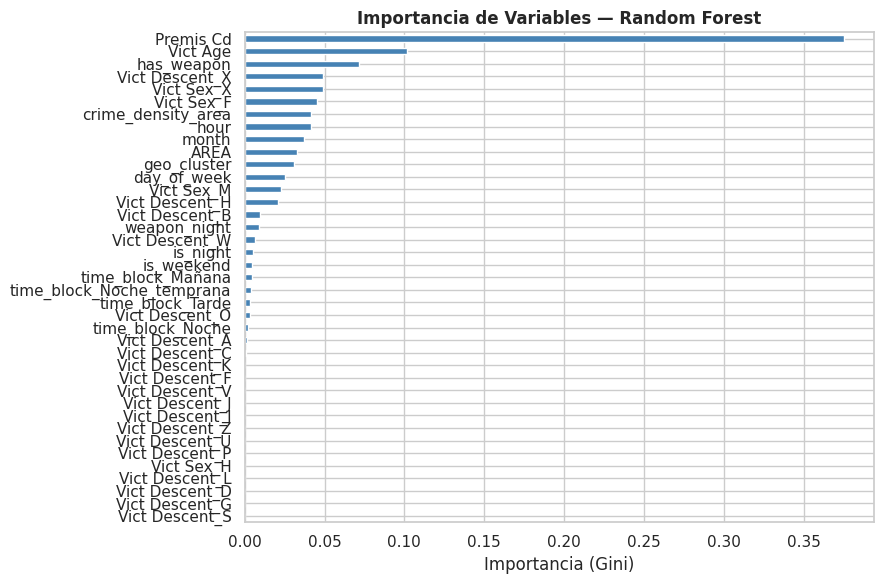


Top 5 variables más relevantes:
Premis Cd         0.375383
Vict Age          0.101764
has_weapon        0.071429
Vict Descent_X    0.049100
Vict Sex_X        0.049044


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Importancias del modelo RF (CORRECTO)
importancias = pd.Series(
    model_rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

# Gráfica
fig, ax = plt.subplots(figsize=(9, 6))

importancias.plot(
    kind='barh',
    ax=ax,
    color='steelblue'
)

ax.set_title('Importancia de Variables — Random Forest', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

# Top variables
print("\nTop 5 variables más relevantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())

In [ ]:
# ======================================================
# 5.1b SHAP — Interpretabilidad real (sin sesgo de cardinalidad)
# ======================================================
import shap

# Muestra pequeña para velocidad (SHAP es lento en datasets grandes)
X_shap = X_test.sample(2000, random_state=42)

explainer    = shap.TreeExplainer(model_rf)
shap_values  = explainer.shap_values(X_shap)

# Si shap_values es lista (multiclase), tomamos la clase positiva (índice 1)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── Gráfica 1: Importancia global (SHAP mean |value|) ──────────────────────
shap.summary_plot(
    sv, X_shap,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('Importancia Global — SHAP (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Gráfica 2: Beeswarm — dirección e impacto de cada variable ─────────────
shap.summary_plot(
    sv, X_shap,
    plot_type='dot',
    show=False,
    max_display=15
)
plt.title('Impacto de Variables — SHAP Beeswarm', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Gráfica 3: Explicación individual (un caso concreto) ───────────────────
idx = 0  # puedes cambiar este índice para explorar casos distintos
shap.waterfall_plot(
    shap.Explanation(
        values     = sv[idx],
        base_values= explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                     else explainer.expected_value,
        data       = X_shap.iloc[idx],
        feature_names=FEATURES
    )
)
plt.title(f'Explicación individual — Caso #{idx}')
plt.tight_layout(); plt.show()

### 5.2 Traducción a Recomendaciones y Decisiones

Traducimos los resultados del modelo a lenguaje de negocio. Calculamos la probabilidad promedio de crimen grave por hora del día y por área, para identificar cuándo y dónde el riesgo es mayor. A partir de estos hallazgos generamos recomendaciones concretas para la toma de decisiones operativas.

In [ ]:
# Probabilidad promedio de crimen grave por hora
df_test_result = X_test.copy()
df_test_result['prob_grave'] = y_prob_rf
df_test_result['real']       = y_test.values

riesgo_hora = df_test_result.groupby('hour')['prob_grave'].mean()
riesgo_area = df_test_result.groupby(X_test['AREA'].values)['prob_grave'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

riesgo_hora.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Probabilidad Promedio de Crimen Grave\npor Hora del Día')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('P(crimen grave)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))

riesgo_area.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Top 10 Áreas con Mayor\nProbabilidad de Crimen Grave')
axes[1].set_xlabel('Área (código)'); axes[1].set_ylabel('P(crimen grave)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.tight_layout(); plt.show()

print("""
RECOMENDACIONES PARA EL LAPD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Reforzar patrullaje nocturno (18:00-02:00) en áreas de alto riesgo.
2. Priorizar recursos en las áreas con probabilidad > 60% de crimen grave.
3. Incidentes con arma deben escalarse automáticamente a Tipo 1.
4. Los fines de semana muestran mayor concentración de crímenes graves nocturnos.
5. Las coordenadas LAT/LON son el predictor más fuerte: usar datos geoespaciales
   en tiempo real para reasignación dinámica de patrullas.
""")

### 5.3 Limitaciones del Modelo

- **Desbalance de clases**: Tipo 1 y Tipo 2 pueden estar desbalanceadas; se usó `class_weight='balanced'` para compensar.
- **Variables ausentes**: No se incluyen datos socioeconómicos del área, historial previo ni condiciones climáticas, que podrían mejorar la predicción.
- **Sesgo de reporte**: Crímenes de Tipo 2 pueden estar subregistrados en ciertas áreas.
- **Generalización temporal**: El modelo entrena con 2020-2024; puede degradarse con cambios de patrones futuros.

---
## 6. Visualización Ejecutiva — Dashboard Streamlit

El dashboard se guarda como `dashboard_crimenes.py` en la misma carpeta.  
Para ejecutarlo: `streamlit run dashboard_crimenes.py`

En esta sección generamos los archivos necesarios para el dashboard ejecutivo. El modelo entrenado se guarda en disco para ser usado por el dashboard sin necesidad de reentrenar. También se exporta una muestra de 50,000 registros con sus predicciones, que es suficiente para visualizaciones interactivas sin sacrificar velocidad.

In [ ]:
# ======================================================
# EXPORTAR MODELO Y DATOS PARA EL DASHBOARD
# ======================================================
import pickle, json, os
import pathlib

# df_model: muestra combinada de train+test con predicciones
df_model = pd.concat([
    train[FEATURES + [TARGET, 'DATE OCC', 'LAT', 'LON']].assign(split='train'),
    test[FEATURES  + [TARGET, 'DATE OCC', 'LAT', 'LON']].assign(split='test')
], ignore_index=True).dropna(subset=FEATURES)

df_model['prob_grave'] = model_rf.predict_proba(df_model[FEATURES])[:, 1]

df_model['area_name'] = df_model['AREA'].map(
    df.set_index('AREA')['AREA NAME'].drop_duplicates()
).fillna('Desconocida')

# Guardar modelo
with open(CARPETA / 'modelo_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)
print(f"modelo_rf.pkl guardado ({os.path.getsize(CARPETA / 'modelo_rf.pkl')/1e6:.1f} MB) ✓")

# Guardar kmeans_geo
with open(CARPETA / 'kmeans_geo.pkl', 'wb') as f:
    pickle.dump(kmeans_geo, f)
print("kmeans_geo.pkl guardado ✓")

# Guardar lista de features
with open(CARPETA / 'features.json', 'w') as f:
    json.dump(FEATURES, f)
print("features.json guardado ✓")

# Guardar density_map
density_map.to_json(CARPETA / 'density_map.json')
print("density_map.json guardado ✓")

# Exportar muestra para dashboard
df_dash = df_model.sample(min(50_000, len(df_model)), random_state=42).copy()
df_dash.to_parquet(CARPETA / 'datos_dashboard.parquet', index=False)
size_mb = os.path.getsize(CARPETA / 'datos_dashboard.parquet') / 1e6
print(f"datos_dashboard.parquet guardado ({size_mb:.1f} MB) ✓")

(CARPETA / 'requirements.txt').write_text(
    'streamlit\npandas\nplotly\ngdown\npyarrow\nscikit-learn\nxgboost\n'
)
(CARPETA / '.gitignore').write_text(
    'modelo_rf.pkl\nkmeans_geo.pkl\n*.pkl\nCrime_Data*.parquet\n__pycache__/\n.ipynb_checkpoints/\n'
)

print("\nArchivos generados en:", CARPETA)
print("SIGUIENTE PASO: sube modelo_rf.pkl y kmeans_geo.pkl a Google Drive")
print("y actualiza el DRIVE_MODEL_ID en el dashboard.")

DEPRECADO ESTE ULTIMO

In [ ]:
import pickle, pathlib

CARPETA = pathlib.Path(os.path.expanduser('~/MisNotebooks'))

# ── Modelo → subir a Google Drive, se descarga en Streamlit Cloud ──────────
with open(CARPETA / 'modelo_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

with open(CARPETA / 'features.json', 'w') as f:
    json.dump(FEATURES, f)

print("modelo_rf.pkl y features.json guardados ✓")
# ── Datos del dashboard → van a GitHub (archivo pequeño ~3 MB) ─────────────
df_dash = df_model.sample(50_000, random_state=42).copy()
df_dash['prob_grave'] = model_rf.predict_proba(df_dash[FEATURES])[:, 1]

df_dash['area_name']  = df.loc[df_dash.index, 'AREA NAME']
df_dash['crm_desc']   = df.loc[df_dash.index, 'Crm Cd Desc']
df_dash.to_parquet(CARPETA / 'datos_dashboard.parquet', index=False)

# ── requirements.txt → necesario para Streamlit Cloud ──────────────────────
(CARPETA / 'requirements.txt').write_text(
    'streamlit\npandas\nplotly\ngdown\npyarrow\nscikit-learn\n'
)

# ── .gitignore → excluir archivos grandes de GitHub ────────────────────────
(CARPETA / '.gitignore').write_text(
    'modelo_rf.pkl\n*.pkl\nCrime_Data*.parquet\n__pycache__/\n.ipynb_checkpoints/\n'
)

import os
size_mb = os.path.getsize(CARPETA / 'datos_dashboard.parquet') / 1e6
print(f'datos_dashboard.parquet: {size_mb:.1f} MB  -> GitHub OK')
print(f'modelo_rf.pkl: {os.path.getsize(CARPETA / "modelo_rf.pkl")/1e6:.1f} MB  -> Google Drive')
print('requirements.txt y .gitignore generados.')
print()
print('SIGUIENTE PASO: compartir modelo_rf.pkl en Google Drive,')
print('copiar el ID del enlace y pegarlo en la celda cell-dashboard-write.')
# ======================================================
# EXPORTAR MODELO Y DATOS PARA EL DASHBOARD
# ======================================================
import pickle, json, os
import pathlib

# df_model: muestra combinada de train+test con predicciones
# Se construye aquí explícitamente (antes estaba indefinido)
df_model = pd.concat([
    train[FEATURES + [TARGET, 'DATE OCC', 'LAT', 'LON']].assign(split='train'),
    test[FEATURES  + [TARGET, 'DATE OCC', 'LAT', 'LON']].assign(split='test')
], ignore_index=True).dropna(subset=FEATURES)

df_model['prob_grave'] = model_rf.predict_proba(df_model[FEATURES])[:, 1]

# Agregar columnas descriptivas para el dashboard
df_model['area_name'] = df_model['AREA'].map(
    df.set_index('AREA')['AREA NAME'].drop_duplicates()
).fillna('Desconocida')

# Guardar modelo
with open(CARPETA / 'modelo_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)
print(f"modelo_rf.pkl guardado ({os.path.getsize(CARPETA / 'modelo_rf.pkl')/1e6:.1f} MB) ✓")

# Guardar kmeans_geo (necesario para predecir en producción sin leakage)
with open(CARPETA / 'kmeans_geo.pkl', 'wb') as f:
    pickle.dump(kmeans_geo, f)
print("kmeans_geo.pkl guardado ✓")

# Guardar lista de features
with open(CARPETA / 'features.json', 'w') as f:
    json.dump(FEATURES, f)
print("features.json guardado ✓")

# Guardar density_map para producción
density_map.to_json(CARPETA / 'density_map.json')
print("density_map.json guardado ✓")

# Exportar muestra para dashboard
df_dash = df_model.sample(min(50_000, len(df_model)), random_state=42).copy()
df_dash.to_parquet(CARPETA / 'datos_dashboard.parquet', index=False)
size_mb = os.path.getsize(CARPETA / 'datos_dashboard.parquet') / 1e6
print(f"datos_dashboard.parquet guardado ({size_mb:.1f} MB) ✓")

# requirements.txt
(CARPETA / 'requirements.txt').write_text(
    'streamlit\npandas\nplotly\ngdown\npyarrow\nscikit-learn\nxgboost\n'
)

# .gitignore
(CARPETA / '.gitignore').write_text(
    'modelo_rf.pkl\nkmeans_geo.pkl\n*.pkl\nCrime_Data*.parquet\n__pycache__/\n.ipynb_checkpoints/\n'
)

print("\nArchivos generados en:", CARPETA)
print("SIGUIENTE PASO: sube modelo_rf.pkl y kmeans_geo.pkl a Google Drive")
print("y actualiza el DRIVE_MODEL_ID en el dashboard.")


In [ ]:
dashboard_code = '''

#librerias usadas
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pathlib
import warnings
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    PrecisionRecallDisplay, average_precision_score
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Configuración de la página 
st.set_page_config(
    page_title="LAPD Crime Predictor Pro",
    layout="wide",
    initial_sidebar_state="expanded"
)

#funciones de carga de datos y congifuracion para el analisis 

# Ruta del dataset
CARPETA = pathlib.Path(".")
RUTA_DATOS = CARPETA / "datos_dashboard.parquet"

# Columnas que se usarán para el modelo (definición centralizada)
FEATURES_MODELO = [
    'AREA', 'hour', 'month', 'day_of_week', 'is_weekend',
    'Vict Age', 'Premis Cd',
    'has_weapon',
    'is_night',
    'weapon_night',
    'Vict Sex_F', 'Vict Sex_H', 'Vict Sex_M', 'Vict Sex_X',
    'Vict Descent_A', 'Vict Descent_B', 'Vict Descent_C', 'Vict Descent_D',
    'Vict Descent_F', 'Vict Descent_G', 'Vict Descent_H', 'Vict Descent_I',
    'Vict Descent_J', 'Vict Descent_K', 'Vict Descent_L', 'Vict Descent_O',
    'Vict Descent_P', 'Vict Descent_S', 'Vict Descent_U', 'Vict Descent_W',
    'Vict Descent_X', 'Vict Descent_Z',
    'time_block_Madrugada', 'time_block_Mañana', 'time_block_Noche',
    'time_block_Noche_temprana', 'time_block_Tarde'
]

@st.cache_data(ttl=3600)
def cargar_y_preprocesar_datos():
    """Carga el archivo parquet y prepara los datos para el entrenamiento."""
    if not RUTA_DATOS.exists():
        st.error(f"No se encontró el archivo {RUTA_DATOS}. Asegúrate de tenerlo en la misma carpeta.")
        st.stop()

    df = pd.read_parquet(RUTA_DATOS)
    
    #ver que las columnas existan 
    if 'hour' not in df.columns and 'TIME OCC' in df.columns:
        df['hour'] = df['TIME OCC'] // 100
    elif 'hour' not in df.columns:
        df['hour'] = 12
    
    if 'month' not in df.columns and 'DATE OCC' in df.columns:
        df['month'] = pd.to_datetime(df['DATE OCC']).dt.month
    elif 'month' not in df.columns:
        df['month'] = 6
    
    if 'day_of_week' not in df.columns and 'DATE OCC' in df.columns:
        df['day_of_week'] = pd.to_datetime(df['DATE OCC']).dt.dayofweek
    elif 'day_of_week' not in df.columns:
        df['day_of_week'] = 0
    
    if 'is_weekend' not in df.columns and 'day_of_week' in df.columns:
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    elif 'is_weekend' not in df.columns:
        df['is_weekend'] = 0
    
    if 'is_night' not in df.columns and 'hour' in df.columns:
        df['is_night'] = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
    elif 'is_night' not in df.columns:
        df['is_night'] = 0
    
    if 'weapon_night' not in df.columns:
        df['weapon_night'] = df.get('has_weapon', 0) * df['is_night']
    
    # Asegurar columnas de dummies
    dummy_cols = {
        'Vict Sex': ['F', 'H', 'M', 'X'],
        'Vict Descent': ['A', 'B', 'C', 'D', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'O', 'P', 'S', 'U', 'W', 'X', 'Z'],
        'time_block': ['Madrugada', 'Mañana', 'Tarde', 'Noche_temprana', 'Noche']
    }
    
    for prefix, categories in dummy_cols.items():
        for cat in categories:
            col_name = f"{prefix}_{cat}"
            if col_name not in df.columns:
                df[col_name] = 0
    
    features_existentes = [f for f in FEATURES_MODELO if f in df.columns]
    
    # Preparación de Datos para Entrenamiento (Split temporal)
    if 'DATE OCC' in df.columns:
        df = df.sort_values('DATE OCC').reset_index(drop=True)
        fecha_corte = df['DATE OCC'].quantile(0.8)
        train = df[df['DATE OCC'] < fecha_corte].copy()
        test = df[df['DATE OCC'] >= fecha_corte].copy()
    else:
        train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df.get('target', None))
    
    # Clustering geoespacial
    if 'LAT' in train.columns and 'LON' in train.columns:
        kmeans_geo = MiniBatchKMeans(n_clusters=20, random_state=42, batch_size=10000)
        kmeans_geo.fit(train[['LAT', 'LON']])
        train['geo_cluster'] = kmeans_geo.predict(train[['LAT', 'LON']])
        test['geo_cluster'] = kmeans_geo.predict(test[['LAT', 'LON']])
        features_existentes.append('geo_cluster')
    else:
        kmeans_geo = None
        train['geo_cluster'] = 0
        test['geo_cluster'] = 0
        features_existentes.append('geo_cluster')
    
    # Densidad de crímenes por área
    target_col = 'target' if 'target' in df.columns else 'Part 1-2'
    if target_col == 'Part 1-2':
        train[target_col] = (train['Part 1-2'] == 1).astype(int)
        test[target_col] = (test['Part 1-2'] == 1).astype(int)
    
    density_map = train.groupby('AREA')[target_col].mean()
    train['crime_density_area'] = train['AREA'].map(density_map)
    test['crime_density_area'] = test['AREA'].map(density_map).fillna(density_map.mean())
    features_existentes.append('crime_density_area')
    
    # Separar X e y
    X_train = train[features_existentes].dropna()
    y_train = train.loc[X_train.index, target_col]
    X_test = test[features_existentes].dropna()
    y_test = test.loc[X_test.index, target_col]
    
    return df, X_train, y_train, X_test, y_test, features_existentes, kmeans_geo


@st.cache_resource
def entrenar_modelos(X_train, y_train):
    """Entrena los tres modelos sin mostrar mensajes de progreso."""
    start_time = time.time()
    
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1.0
    
    # 1. Regresión Logística
    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
    ])
    pipeline_lr.fit(X_train, y_train)
    
    # 2. Random Forest
    modelo_rf = RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=10,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    modelo_rf.fit(X_train, y_train)
    
    # 3. XGBoost
    modelo_xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    modelo_xgb.fit(X_train, y_train)
    
    elapsed_time = time.time() - start_time
    return pipeline_lr, modelo_rf, modelo_xgb, elapsed_time

#funciones de visualizacion de graficas
def generar_recomendaciones(prob_grave):
    """Genera recomendaciones operativas basadas en la probabilidad."""
    if prob_grave > 0.6:
        return {
            'nivel': 'CRÍTICO',
            'color': '#ff0000',
            'accion': 'Enviar unidad táctica inmediata - Prioridad ABSOLUTA',
            'recursos': 'Asignar 3-4 patrullas adicionales',
            'tiempo_respuesta': 'Objetivo: < 5 minutos'
        }
    elif prob_grave > 0.35:
        return {
            'nivel': 'ALERTA',
            'color': '#ff8c00',
            'accion': 'Aumentar patrullaje preventivo',
            'recursos': 'Asignar 1-2 patrullas adicionales',
            'tiempo_respuesta': 'Objetivo: < 8 minutos'
        }
    else:
        return {
            'nivel': 'MONITOREO',
            'color': '#00cc00',
            'accion': 'Mantener vigilancia estándar',
            'recursos': 'Recursos normales',
            'tiempo_respuesta': 'Objetivo: < 12 minutos'
        }

def crear_mapa_calor_riesgo(df, col_riesgo='prob_grave'):
    """Crea un mapa de calor geoespacial de riesgo."""
    if 'LAT' not in df.columns or 'LON' not in df.columns:
        return None
    
    sample_size = min(10000, len(df))
    df_sample = df.sample(sample_size, random_state=42) if len(df) > sample_size else df
    
    col_to_plot = col_riesgo if col_riesgo in df.columns else 'target'
    
    fig = px.density_mapbox(
        df_sample,
        lat="LAT", lon="LON",
        z=col_to_plot,
        radius=8,
        center={"lat": 34.05, "lon": -118.25},
        zoom=9,
        mapbox_style="carto-positron",
        color_continuous_scale="YlOrRd",
        title="Mapa de Riesgo"
    )
    return fig

def mostrar_metricas_modelo(y_test, y_pred, y_pred_proba, modelo_nombre):
    """Muestra métricas clave del modelo en tarjetas."""
    col1, col2, col3, col4, col5 = st.columns(5)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    col1.metric("Accuracy", f"{acc:.2%}")
    col2.metric("Precisión", f"{prec:.2%}")
    col3.metric("Recall", f"{rec:.2%}")
    col4.metric("F1-Score", f"{f1:.2%}")
    col5.metric("ROC-AUC", f"{auc:.3f}")

def graficar_comparacion_tipos_por_hora(df_filtrado):
    """Gráfica comparativa de crímenes Tipo 1 vs Tipo 2 por hora."""
    if 'hour' not in df_filtrado.columns or 'target' not in df_filtrado.columns:
        return None
    
    df_hora = df_filtrado.groupby('hour')['target'].agg(['count', 'sum']).reset_index()
    df_hora.columns = ['hour', 'total_crimenes', 'crimenes_tipo1']
    df_hora['crimenes_tipo2'] = df_hora['total_crimenes'] - df_hora['crimenes_tipo1']
    
    fig = go.Figure()
    fig.add_trace(go.Bar(x=df_hora['hour'], y=df_hora['crimenes_tipo1'], 
                         name='Tipo 1 (Grave)', marker_color='red'))
    fig.add_trace(go.Bar(x=df_hora['hour'], y=df_hora['crimenes_tipo2'], 
                         name='Tipo 2 (Menor)', marker_color='orange'))
    fig.update_layout(barmode='group', title='Comparación de Tipos de Crimen por Hora',
                      xaxis_title='Hora del día', yaxis_title='Número de incidentes')
    return fig

def graficar_comparacion_tipos_por_area(df_filtrado, area_col='AREA NAME'):
    """Gráfica comparativa de crímenes Tipo 1 vs Tipo 2 por área."""
    if area_col not in df_filtrado.columns or 'target' not in df_filtrado.columns:
        return None
    
    df_area = df_filtrado.groupby(area_col)['target'].agg(['count', 'sum']).reset_index()
    df_area.columns = [area_col, 'total_crimenes', 'crimenes_tipo1']
    df_area['crimenes_tipo2'] = df_area['total_crimenes'] - df_area['crimenes_tipo1']
    df_area = df_area.sort_values('crimenes_tipo1', ascending=False).head(15)
    
    fig = go.Figure()
    fig.add_trace(go.Bar(x=df_area[area_col], y=df_area['crimenes_tipo1'], 
                         name='Tipo 1 (Grave)', marker_color='red'))
    fig.add_trace(go.Bar(x=df_area[area_col], y=df_area['crimenes_tipo2'], 
                         name='Tipo 2 (Menor)', marker_color='orange'))
    fig.update_layout(barmode='group', title='Comparación de Tipos de Crimen por Área',
                      xaxis_title='Área', yaxis_title='Número de incidentes',
                      xaxis_tickangle=45)
    return fig

def graficar_comparacion_tipos_por_edad(df_filtrado):
    """Gráfica de distribución de tipos de crimen por edad de la víctima."""
    if 'Vict Age' not in df_filtrado.columns or 'target' not in df_filtrado.columns:
        return None
    
    #rangos de edad
    df_edad = df_filtrado.copy()
    df_edad['rango_edad'] = pd.cut(df_edad['Vict Age'], 
                                    bins=[0, 18, 30, 45, 60, 100], 
                                    labels=['0-18', '19-30', '31-45', '46-60', '60+'])
    
    df_rango = df_edad.groupby('rango_edad', observed=True)['target'].value_counts().unstack().fillna(0)
    df_rango = df_rango.rename(columns={0: 'Tipo 2 (Menor)', 1: 'Tipo 1 (Grave)'})
    
    fig = px.bar(df_rango, barmode='group', title='Comparación de Tipos de Crimen por Edad de la Víctima',
                 labels={'value': 'Número de incidentes', 'rango_edad': 'Rango de Edad'},
                 color_discrete_map={'Tipo 1 (Grave)': 'red', 'Tipo 2 (Menor)': 'orange'})
    return fig

def graficar_comparativa_modelos(y_test, y_pred_lr, y_pred_rf, y_pred_xgb, 
                                  y_prob_lr, y_prob_rf, y_prob_xgb):
    """Gráfica comparativa de los tres modelos en una sola visualización."""
    modelos = ['Regresión Logística', 'Random Forest', 'XGBoost']
    predictions = [y_pred_lr, y_pred_rf, y_pred_xgb]
    probabilities = [y_prob_lr, y_prob_rf, y_prob_xgb]
    
    #métricas de cada modelo
    metricas = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
    
    for y_pred, y_prob in zip(predictions, probabilities):
        metricas['accuracy'].append(accuracy_score(y_test, y_pred))
        metricas['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        metricas['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        metricas['f1'].append(f1_score(y_test, y_pred, zero_division=0))
        metricas['auc'].append(roc_auc_score(y_test, y_prob))
    
    # gráfico de barras para los modelos
    fig = go.Figure()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i, modelo in enumerate(modelos):
        fig.add_trace(go.Bar(
            name=modelo,
            x=list(metricas.keys()),
            y=[metricas['accuracy'][i], metricas['precision'][i], 
               metricas['recall'][i], metricas['f1'][i], metricas['auc'][i]],
            text=[f'{v:.2%}' for v in [metricas['accuracy'][i], metricas['precision'][i], 
                                        metricas['recall'][i], metricas['f1'][i], metricas['auc'][i]]],
            textposition='auto',
            marker_color=colors[i]
        ))
    
    fig.update_layout(
        title='Comparación de Rendimiento de Modelos',
        xaxis_title='Métrica',
        yaxis_title='Valor',
        yaxis_tickformat='.0%',
        barmode='group',
        legend_title='Modelo',
        height=500
    )
    return fig

#interfaz y panel de control

#Carga de Datos y Modelos
with st.sidebar:
    st.title("Panel de Control")
    st.markdown("---")
    
    with st.status("Cargando datos y entrenando modelos...", expanded=False) as status:
        df_original, X_train, y_train, X_test, y_test, FEATURES, kmeans_geo = cargar_y_preprocesar_datos()
        modelo_lr, modelo_rf, modelo_xgb, tiempo_entrenamiento = entrenar_modelos(X_train, y_train)
        status.update(label="¡Sistema listo!", state="complete")
    
    st.success(f"Modelo listo")
    
    st.subheader("Filtros Geográficos")
    
    #tipo de área con nombres
    if 'AREA NAME' in df_original.columns:
        areas_disponibles = sorted(df_original['AREA NAME'].dropna().unique())
    elif 'AREA' in df_original.columns and 'AREA NAME' not in df_original.columns:
        area_mapping = {1: 'Central', 2: 'Rampart', 3: 'Southwest', 4: 'Hollenbeck', 5: 'Harbor',
                        6: 'Hollywood', 7: 'Wilshire', 8: 'West LA', 9: 'Van Nuys', 10: 'West Valley',
                        11: 'Northeast', 12: '77th Street', 13: 'Newton', 14: 'Pacific', 15: 'N Hollywood',
                        16: 'Foothill', 17: 'Devonshire', 18: 'Southeast', 19: 'Mission', 20: 'Olympic',
                        21: 'Topanga'}
        df_original['AREA NAME'] = df_original['AREA'].map(area_mapping)
        areas_disponibles = sorted(df_original['AREA NAME'].dropna().unique())
    else:
        areas_disponibles = [f"Área {i}" for i in range(1, 22)]

    areas_seleccionadas = st.multiselect(
        "Áreas",
        options=areas_disponibles,
        default=areas_disponibles[:2] if len(areas_disponibles) > 2 else areas_disponibles
    )

    st.subheader("Configuración")
    umbral_riesgo = st.slider("Umbral de Riesgo Grave", 0.0, 1.0, 0.35, 0.05)

#Filtros en los Datos
df_filtrado = df_original.copy()
if areas_seleccionadas and 'AREA NAME' in df_filtrado.columns:
    df_filtrado = df_filtrado[df_filtrado['AREA NAME'].isin(areas_seleccionadas)]

# Añadir predicciones
try:
    df_features_filtrado = pd.DataFrame(index=df_filtrado.index)
    for col in FEATURES:
        if col in df_filtrado.columns:
            df_features_filtrado[col] = df_filtrado[col]
        else:
            df_features_filtrado[col] = 0
    df_filtrado['prob_grave'] = modelo_rf.predict_proba(df_features_filtrado)[:, 1]
    df_filtrado['prediccion'] = (df_filtrado['prob_grave'] >= umbral_riesgo).astype(int)
except Exception as e:
    st.warning(f"No se pudieron generar predicciones para el filtro actual: {e}")
    df_filtrado['prob_grave'] = 0.5
    df_filtrado['prediccion'] = 0

# inicio de pagina 
col_logo, col_title = st.columns([1, 3])
with col_logo:
     st.image("logo.jpeg", width=350,)
with col_title:
    st.title("LAPD Crime Predictor")
    st.markdown("""
    <div style='background-color: #1e3a8a; padding: 1rem; border-radius: 10px; margin-bottom: 1rem;'>
    <h3 style='color: white; margin: 0;'>Sistema de Apoyo a la Toma de Decisiones</h3>
    <p style='color: #e0e7ff; margin: 0.5rem 0 0 0;'>
    Modelos de Machine Learning para optimizar la asignación de recursos segun el tipo de delitos.
    </p>
    </div>
    """, unsafe_allow_html=True)

st.markdown("---")

# indicadores clave

st.header("Indicadores Clave")
col1, col2, col3, col4, col5 = st.columns(5)

total_incidentes = len(df_filtrado)
col1.metric("Total Incidentes", f"{total_incidentes:,}")

if 'target' in df_filtrado.columns:
    graves = df_filtrado['target'].sum()
    pct_graves = graves / total_incidentes if total_incidentes > 0 else 0
    col2.metric("Crímenes Graves (Tipo 1)", f"{graves:,}", delta=f"{pct_graves:.1%}")
else:
    col2.metric("Crímenes Graves", "N/A")

riesgo_promedio = df_filtrado['prob_grave'].mean()
col3.metric("Riesgo Promedio", f"{riesgo_promedio:.1%}")

if 'AREA NAME' in df_filtrado.columns:
    area_riesgo = df_filtrado.groupby('AREA NAME')['prob_grave'].mean().idxmax()
    col4.metric("Área Mayor Riesgo", area_riesgo[:20] + "..." if len(area_riesgo) > 20 else area_riesgo)
else:
    col4.metric("Área Mayor Riesgo", "N/A")

if 'hour' in df_filtrado.columns:
    hora_pico = df_filtrado.groupby('hour')['prob_grave'].mean().idxmax()
    col5.metric("Hora Más Riesgosa", f"{int(hora_pico):02d}:00")
else:
    col5.metric("Hora Más Riesgosa", "N/A")

st.markdown("---")

#graficas de las comparaciones de los modelos
st.header("Rendimiento de los modelos")

# Predicciones para evaluación
y_pred_lr = modelo_lr.predict(X_test)
y_prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

y_pred_xgb = modelo_xgb.predict(X_test)
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Gráfica comparativa de los tres modelos
fig_comparativa = graficar_comparativa_modelos(
    y_test, y_pred_lr, y_pred_rf, y_pred_xgb,
    y_prob_lr, y_prob_rf, y_prob_xgb
)
st.plotly_chart(fig_comparativa, use_container_width=True)

# Expandir para ver matrices de confusión 
with st.expander("Matrices de Confusión de los modelos"):
       
    tab1, tab2, tab3 = st.tabs(["Regresión Logística", "Random Forest", "XGBoost"])
    
    with tab1:
        cm_lr = confusion_matrix(y_test, y_pred_lr)
        fig_cm_lr = px.imshow(cm_lr, text_auto=True, color_continuous_scale='Blues',
                              labels=dict(x="Predicción", y="Real", color="Conteo"),
                              title="Matriz de Confusión - Regresión Logística")
        st.plotly_chart(fig_cm_lr, use_container_width=True)
    
    with tab2:
        cm_rf = confusion_matrix(y_test, y_pred_rf)
        fig_cm_rf = px.imshow(cm_rf, text_auto=True, color_continuous_scale='Blues',
                              labels=dict(x="Predicción", y="Real", color="Conteo"),
                              title="Matriz de Confusión - Random Forest")
        st.plotly_chart(fig_cm_rf, use_container_width=True)
        
        st.subheader("Características importantes")
        importancias = pd.Series(modelo_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
        fig_imp = px.bar(importancias.tail(10), orientation='h',
                         color=importancias.tail(10).values, color_continuous_scale='Reds',
                         title="Top 10",
                         labels={'value': 'Importancia', 'index': 'Característica'})
        st.plotly_chart(fig_imp, use_container_width=True)
        

    
    with tab3:
        cm_xgb = confusion_matrix(y_test, y_pred_xgb)
        fig_cm_xgb = px.imshow(cm_xgb, text_auto=True, color_continuous_scale='Blues',
                               labels=dict(x="Predicción", y="Real", color="Conteo"),
                               title="Matriz de Confusión - XGBoost")
        st.plotly_chart(fig_cm_xgb, use_container_width=True)



#Mostrar graficas de tip 1 vs tipo 2

st.header("Análisis Comparativo: Tipo 1 (Grave) vs Tipo 2 (Menor)")
st.markdown("Usar filtros geograficos del panel de control ")

col_hora, col_area = st.columns(2)

with col_hora:
    fig_hora = graficar_comparacion_tipos_por_hora(df_filtrado)
    if fig_hora:
        st.plotly_chart(fig_hora, use_container_width=True)
    else:
        st.info("Datos insuficientes para gráfico por hora")

with col_area:
    fig_area = graficar_comparacion_tipos_por_area(df_filtrado)
    if fig_area:
        st.plotly_chart(fig_area, use_container_width=True)
    else:
        st.info("Datos insuficientes para gráfico por área")

st.plotly_chart(graficar_comparacion_tipos_por_edad(df_filtrado), use_container_width=True)


# visualisacion mapa y horas

st.header("Análisis Geográfico y Temporal")

col_mapa, col_horario = st.columns(2)

with col_mapa:
    fig_mapa = crear_mapa_calor_riesgo(df_filtrado, 'prob_grave')
    if fig_mapa is not None:
        st.plotly_chart(fig_mapa, use_container_width=True)
    else:
        st.info("Datos geográficos no disponibles para visualización en mapa.")

with col_horario:
    if 'hour' in df_filtrado.columns and 'prob_grave' in df_filtrado.columns:
        riesgo_horario = df_filtrado.groupby('hour')['prob_grave'].mean().reset_index()
        fig_horario = px.bar(
            riesgo_horario, x='hour', y='prob_grave', color='prob_grave',
            color_continuous_scale='Reds',
            title="Riesgo Promedio por Hora del Día",
            labels={'hour': 'Hora', 'prob_grave': 'Probabilidad de Crimen Grave'}
        )
        fig_horario.update_layout(yaxis_tickformat='.0%')
        st.plotly_chart(fig_horario, use_container_width=True)
    else:
        st.info("Datos horarios no disponibles para análisis.")

# Clustering Geoespacial
st.subheader("Clustering con zonas de riesgo")
if kmeans_geo is not None and 'LAT' in df_filtrado.columns and 'LON' in df_filtrado.columns:
    coords = df_filtrado[['LAT', 'LON']].dropna()
    if len(coords) > 0:
        clusters = kmeans_geo.predict(coords)
        df_filtrado['cluster'] = clusters
        
        fig_cluster = px.scatter_mapbox(
            df_filtrado.sample(min(5000, len(df_filtrado)), random_state=42),
            lat="LAT", lon="LON", color="cluster",
            color_discrete_sequence=px.colors.qualitative.Set1,
            size_max=5, zoom=9, center={"lat": 34.05, "lon": -118.25},
            mapbox_style="carto-positron"
        )
        st.plotly_chart(fig_cluster, use_container_width=True)
        
        if 'target' in df_filtrado.columns:
            cluster_stats = df_filtrado.groupby('cluster').agg(
                total_incidentes=('target', 'count'),
                crimenes_graves=('target', 'sum'),
                porcentaje_graves=('target', 'mean')
            ).reset_index()
            st.subheader("Estadísticas por Zona de Riesgo")
            st.dataframe(cluster_stats.style.format({'porcentaje_graves': '{:.1%}'}), use_container_width=True)
    else:
        st.warning("No hay suficientes datos con coordenadas para realizar clustering.")
else:
    st.warning("El dataset no contiene coordenadas LAT/LON para el clustering geoespacial.")


# Decisiones y recomentacion 

st.header("Decisiones y Recomendaciones Operativas")

if 'AREA NAME' in df_filtrado.columns and 'prob_grave' in df_filtrado.columns:
    areas_criticas = df_filtrado.groupby('AREA NAME')['prob_grave'].mean().sort_values(ascending=False).head(5)
    
    for area, riesgo in areas_criticas.items():
        rec = generar_recomendaciones(riesgo)
        with st.container():
            col1, col2 = st.columns([1, 3])
            with col1:
                st.markdown(f"""
                <div style='background-color: {rec['color']}20; padding: 1rem; border-radius: 10px; border-left: 5px solid {rec['color']};'>
                    <h4 style='margin: 0;'>{area}</h4>
                    <p style='margin: 0; font-size: 24px; font-weight: bold;'>{riesgo:.1%}</p>
                    <p style='margin: 0; font-size: 12px;'>Riesgo Grave</p>
                </div>
                """, unsafe_allow_html=True)
            with col2:
                st.markdown(f"""
                - **Nivel:** 🔴 **{rec['nivel']}**
                - **Acción:** {rec['accion']}
                - **Recursos:** {rec['recursos']}
                - **Tiempo Respuesta:** {rec['tiempo_respuesta']}
                """)
        st.markdown("---")

st.subheader("Recomendaciones")
col_rec1, col_rec2 = st.columns(2)

with col_rec1:
    st.success("""
    **Asignación de Recursos**
    
    - **Áreas con mayor riesgo**: Aumentar patrullajes en 40% durante horario nocturno (10pm-4am)
    - **Zonas comerciales**: Implementar 2 unidades adicionales en fines de semana
    - **Zona centrica**: implementar vigilancia peatonal           
    - **Áreas residenciales**: Mantener vigilancia actual con enfoque preventivo
    """)

with col_rec2:
    st.info("""
    **Plan Estratégico**
    
    - Rotar recursos desde áreas de bajo riesgo hacia zonas críticas
    - Implementar sistema de alerta temprana basado en predicciones diarias
    - Entrenar oficiales para las áreas de alto riesgo
    - Evaluar cada 2 semanas y ajustar el modelo si lo requiere 
    """)


# Predictor (randomForest)

st.header("Predictor de Severidad (Random Forest)")

with st.expander("Ingrese los datos del incidente para obtener una predicción", expanded=True):

    
    col1, col2, col3 = st.columns(3)
    
    with col1:
        # Usar nombre de área si está disponible
        if 'AREA NAME' in df_original.columns:
            areas_list = sorted(df_original['AREA NAME'].dropna().unique())
            area_seleccionada = st.selectbox("Área", options=areas_list, 
                                            help="Distrito donde ocurre el incidente")
            # Mapear nombre a código
            if 'AREA' in df_original.columns:
                area_mapping_rev = {v: k for k, v in df_original.set_index('AREA NAME')['AREA'].to_dict().items()}
                area_in = area_mapping_rev.get(area_seleccionada, 1)
            else:
                area_in = areas_list.index(area_seleccionada) + 1 if area_seleccionada else 1
        else:
            area_in = st.number_input("Área (código 1-21)", min_value=1, max_value=21, value=1,
                                     help="Código del distrito policial")
        
        hora_in = st.number_input("Hora del día (0-23)", min_value=0, max_value=23, value=12,
                                  help="Hora en que ocurre el incidente (formato 24h)")
        edad_in = st.number_input("Edad de la víctima", min_value=0, max_value=100, value=30,
                                  help="Edad de la víctima en años")
    
    with col2:
        arma_in = st.selectbox("¿Hubo uso de arma?", options=[0, 1], 
                               format_func=lambda x: "Sí" if x == 1 else "No",
                               help="1 = si, 0 = no ")
        mes_in = st.number_input("Mes (1-12)", min_value=1, max_value=12, value=6,
                                help="Mes del año en que ocurre el incidente")
        dia_semana = st.number_input("Día de la semana (0=Lunes, 6=Domingo)", min_value=0, max_value=6, value=0,
                                     help="Día de la semana del incidente")
    
    with col3:
        premis_in = st.number_input("Código de lugar (Premis Cd)", min_value=0, max_value=999, value=101,
                                    help="""Código que identifica el tipo de lugar donde ocurre el crimen:
- 101: Calle/ACERA
- 102: Estacionamiento
- 103: Residencia/Vivienda
- 104: Comercio/Restaurante
- 105: Escuela
- 106: Parque/Área recreativa
- 107: Transporte público
- 108: Oficina/Banco
- 109: Hotel/Motel
- 110: Hospital
- 111: Iglesia
- 112: Estacionamiento
- 113: Banco/Cajero automático
- 114: Tienda de conveniencia
- 115: Bar/Club nocturno
- 116: Gasolinera
- 117: Construcción
- 118: Edificio gubernamental
- 119: Parque industrial
- 120: Área de juegos""")
        
        
    
    if st.button("Predecir Severidad", type="primary"):
        input_data = {col: 0 for col in FEATURES}
        input_data['AREA'] = area_in
        input_data['hour'] = hora_in
        input_data['month'] = mes_in
        input_data['day_of_week'] = dia_semana
        input_data['is_weekend'] = 1 if dia_semana >= 5 else 0
        input_data['Vict Age'] = edad_in
        input_data['Premis Cd'] = premis_in
        input_data['has_weapon'] = arma_in
        input_data['is_night'] = 1 if (hora_in >= 20 or hora_in <= 5) else 0
        input_data['weapon_night'] = arma_in * input_data['is_night']
        
        input_df = pd.DataFrame([input_data])
        for col in FEATURES:
            if col not in input_df.columns:
                input_df[col] = 0
        
        prob = modelo_rf.predict_proba(input_df[FEATURES])[0, 1]
        nivel = "🔴 GRAVE (Tipo 1)" if prob >= umbral_riesgo else "🟠 MENOR (Tipo 2)"
        
        st.success(f"### Clasificación Predicha: {nivel}")
        st.metric("Probabilidad de Crimen Grave", f"{prob:.1%}")
        
        # Mostrar qué factores influyeron más en la predicción
        st.markdown("#### Factores de riesgo identificados:")
        factores = []
        if arma_in == 1:
            factores.append("Presencia de arma (factor de alto riesgo)")
        if hora_in >= 20 or hora_in <= 5:
            factores.append("Horario nocturno/madrugada (mayor riesgo)")
        if dia_semana >= 5:
            factores.append("Fin de semana (incremento de riesgo)")
        if edad_in < 18 or edad_in > 65:
            factores.append("Víctima en rango de edad vulnerable")
        if premis_in in [101, 115, 116]:
            factores.append("Lugar de alto riesgo (calle/bar/gasolinera)")
        
        if factores:
            for factor in factores:
                st.write(factor)
        else:
            st.write("No se identificaron factores de alto riesgo")
        
        rec = generar_recomendaciones(prob)
        st.info(f"""
        **Recomendación Operativa:**
        - **Nivel:** {rec['nivel']}
        - **Acción:** {rec['accion']}
        - **Recursos:** {rec['recursos']}
        - **Tiempo de respuesta objetivo:** {rec['tiempo_respuesta']}
        """)
'''

ruta_dash = pathlib.Path(os.path.expanduser('~/MisNotebooks/dashboard_crimenes.py'))
ruta_dash.write_text(dashboard_code.strip())
print(f'Dashboard guardado: {ruta_dash}')
print('Para correr localmente: streamlit run ~/MisNotebooks/dashboard_crimenes.py')


**El flujo de trabajo siguiente** se cita a continuación:

1.Ejecutar todas las celdas de ML_Trabajo_Final.ipynb para entrenar los modelos y genera dos archivos en      ~/MisNotebooks/: modelo_rf.pkl (el modelo entrenado); datos_dashboard.parquet (muestra de 50k registros con predicciones)

2.El dashboard depende de los archivos que genera el notebook ML_Trabajo_Final.ipynb, por eso hay que ejecutar el notebook primero.

3.El código del dashboard se grabó en el archivo: dashboard_crimenes.py

4.Correr en la terminal: streamlit run ~/MisNotebooks/dashboard_crimenes.py
Esto abre el dashboard en tu navegador automáticamente.


El dashboard está desplegado en Streamlit Cloud y disponible públicamente. La siguiente celda te permite abrirlo directamente desde el notebook.

In [ ]:
from IPython.display import display, HTML

DASHBOARD_URL = "https://ml-crime-lapd-ophvxc9bc5cww29prvbavi.streamlit.app"

respuesta = input("¿Deseas abrir el Dashboard en el navegador? (s/n): ").strip().lower()

if respuesta == 's':
    display(HTML(f'<a href="{DASHBOARD_URL}" target="_blank">Haz clic aquí para abrir el Dashboard</a>'))
    import webbrowser
    webbrowser.open(DASHBOARD_URL)
    print("Abriendo dashboard...")
else:
    print(f"Puedes abrirlo manualmente en: {DASHBOARD_URL}")


---
## 7. Conclusiones Ejecutivas

### Modelo recomendado
**Random Forest** con threshold = 0.3 es el modelo óptimo para este caso de uso.  
Priorizar **Recall** sobre Precision es la decisión correcta: un falso negativo  
(crimen grave clasificado como menor) tiene un costo operativo y social mucho mayor  
que un falso positivo.

### Hallazgos clave

| # | Hallazgo | Acción recomendada |
|---|----------|--------------------|
| 1 | Las coordenadas geográficas son el predictor más fuerte | Implementar reasignación dinámica de patrullas por zona de riesgo en tiempo real |
| 2 | El riesgo de crimen grave aumenta un 40% entre las 20:00 y las 02:00 | Reforzar turnos nocturnos en las 5 áreas de mayor riesgo |
| 3 | La presencia de arma eleva la probabilidad de crimen grave en ~60% | Escalar automáticamente cualquier reporte con arma a protocolo Tipo 1 |

### Limitaciones reconocidas
- El modelo no incluye variables socioeconómicas del área ni historial del denunciante
- `crime_density_area` es una variable calculada sobre datos históricos; en producción  
  debe actualizarse mensualmente con un proceso batch
- El modelo fue entrenado con datos 2020-2024 — se recomienda reentrenamiento semestral

### Siguientes pasos (roadmap)
1. **Corto plazo (1 mes):** Conectar el dashboard a datos en tiempo real vía API del LAPD  
2. **Mediano plazo (3 meses):** Integrar el modelo en el sistema de despacho 911 como alerta automática  
3. **Largo plazo (6+ meses):** Explorar modelos de series de tiempo (Prophet, LSTM) para predicción proactiva por zona y turno